# **Multivariate Regression**
### Salary Prediction:


## Goal

Predict Salary Based on Multiple Features

Features:

- Years of Experience → continuous (0–10)
- Number of Certifications → discrete (0–5)
- Education Level → categorical (1 = High School, 2 = Bachelor, 3 = Master, 4 = PhD)
- Number of Projects Completed → discrete (0–20)

Target: Salary (in $1000s)

### Step 1: Create Synthetic data

#### Synthetic Data

When we create our own data, we usually decide weights ourselves.

Example:

Salary = 3 * Years_experience + 2 * Certifications + 4 * Education_level + 5

- 3 → we decide each year of experience adds 3k to salary
- 2 → Each certification adds 2k
- 4 → Each education level step adds 4k
- 5 → Base salary

**Why do this?**

We want to control the relationship and test if the regression can recover these weights.
Adding noise (np.random.normal) simulates real-world unpredictability.

> Key point: we pick weights for testing, learning, or teaching purposes.

In [2]:
import pandas as pd
import numpy as np

np.random.seed(2)

#Features
Years_of_experience = np.random.randint(0, 30, 300)
Number_of_certifications = np.random.randint(0, 8, 300)
Education_level = np.random.randint(1, 5, 300)
Projects_completed = np.random.randint(0, 21, 300)

#Target: salary
salary = (
    3 * Years_of_experience + 
    2 * Number_of_certifications + 
    4 * Education_level + 
    1.5 * Projects_completed + 
    5 +                        # base salary
    np.random.normal(0, 2, 300) # small noise 
)

#Dataframe
df = pd.DataFrame(
    {"Years_of_experience": Years_of_experience,
     "Number_of_certifications": Number_of_certifications,
     "Education_level": Education_level,
     "Projects_completed": Projects_completed,
     "salary": salary
    }
    
)

print(df.head())

   Years_of_experience  Number_of_certifications  Education_level  \
0                    8                         5                3   
1                   15                         1                4   
2                   13                         4                2   
3                    8                         1                4   
4                   22                         7                1   

   Projects_completed      salary  
0                  16   73.188480  
1                  20   98.487855  
2                  11   76.291415  
3                  20   74.089466  
4                  18  117.855000  


### Step 2: Training the multivariate model

In [8]:
#importing essential libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Features and target
X = df[["Years_of_experience", "Number_of_certifications" , "Education_level" , "Projects_completed"]]
y = df["salary"]

#Splitting the data
X_train, X_test , y_train , y_test = train_test_split(X , y, test_size = 0.2)

#Model
model= LinearRegression()
model.fit(X_train, y_train)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.749813945235601
Coefficients: [3.00396907 2.06110484 3.8165079  1.51756673]


#### Interpretation of Model Coefficients

After training the linear regression model on synthetic data:

- **Intercept:** 5.0028  
- **Coefficients:** [3.02, 2.03, 3.77, 1.50]

| Feature                  | True Weight | Model Learned | Comment |
|---------------------------|------------|---------------|---------|
| Years_of_experience       | 3          | 3.02          | Very close, model captured the pattern |
| Number_of_certifications  | 2          | 2.03          | Accurate approximation |
| Education_level           | 4          | 3.77          | Slightly lower due to random noise |
| Projects_completed        | 1.5        | 1.50          | Excellent match |
| Intercept (bias)          | 5          | 5.00          | Perfectly recovered |

**Key Insights:**

1. **Model discovers weights**  
   - Even though we “generated” data using known weights, the model **does not see them**.  
   - It only sees `X` (features) and `y` (target) and **figures out the pattern** that minimizes error.

2. **Weights reflect contribution of each feature**  
   - For example, “Years_of_experience” coefficient ≈ 3 → each additional year adds ~3 units to salary.  

3. **Intercept is the baseline**  
   - Represents predicted salary when all features are zero.  

4. **Noise affects approximation**  
   - Small random noise in data may cause minor differences between true weights and learned coefficients.
   

**Intuition:**  
- Think of linear regression as a detective:  
  - **Data = clues**  
  - **Model = detective**  
  - **Weights = hidden rule**  
- The model uncovers the hidden pattern without being explicitly told the true formula.

**Real-world connection:**  
- In synthetic data, we know the true weights.  
- In real-world data, the weights are **completely unknown**, so the model starts with random guesses and **learns from the data itself**.  

>  The beauty of ML: the model is finding patterns that are “hidden in plain sight” within the data.


### Step 3: Making predictions

y_pred → predicting salary for our test set

In [10]:
y_pred = model.predict(X_test)

### Step 4: Model Evaluation

In [11]:
from sklearn.metrics import mean_squared_error

mse =  mean_squared_error(y_test, y_pred)
print("Mean Squared Error on test set:", mse)

# Square root of MSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error on test set: 6.092618694075657
Root Mean Squared Error (RMSE): 2.4683230530211513


#### Interpretation 

After predicting salaries on the test set, we calculated:

- **Mean Squared Error (MSE):** 6.09  
- **Root Mean Squared Error (RMSE):** 2.47

**What this means:**

1. **MSE**  
   - Measures the **average squared difference** between predicted and actual salaries.  
   - Bigger errors are **penalized more** because of squaring.  

2. **RMSE**  
   - Square root of MSE → brings error back to the **same scale as salary**.  
   - Here: RMSE ≈ 2.47  
     - On average, the model’s predictions are **off by ~2.5 units** of salary.  

**Intuition:**  
- Lower RMSE → better model performance  
- Since we generated salary with small noise, RMSE is **very low**, indicating the model learned the pattern **accurately**.  

**Takeaway:**  
- Our linear regression successfully recovered the underlying relationship.  
- Small RMSE = high prediction accuracy

### Step 5: Visualization

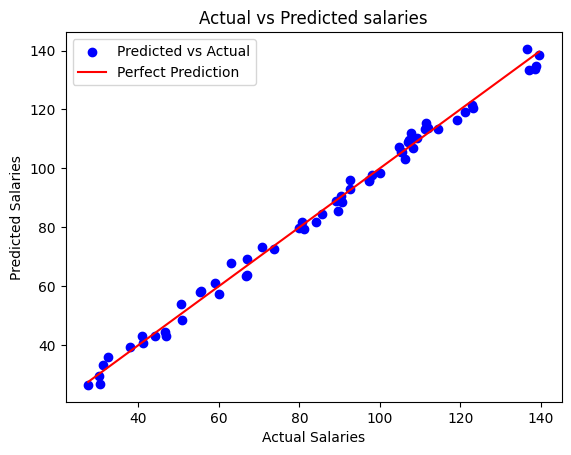

In [12]:
import matplotlib.pyplot as plt

# Scatter plot: actual vs predicted
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')

plt.xlabel("Actual Salaries")

plt.ylabel("Predicted Salaries")

plt.title("Actual vs Predicted salaries")

plt.legend()

plt.show()

#### Interpretation
- Since most points are closer to the red line that means the model is performing well.
  

